# 🌍 Global Temperature Trends — Data Analysis
**Libraries:** NumPy · Pandas · Matplotlib  
**Objective:** Generate, analyse, and visualize synthetic monthly temperature data across 10 global cities.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Data Preparation
Generate a synthetic dataset of average monthly temperatures (°C) for 10 cities over 12 months.  
Temperatures range from **-5°C to 35°C** using `np.random.uniform()`.

In [2]:
city_names = [
    "Tokyo", "Cairo", "Toronto", "Sydney",
    "Moscow", "Mumbai", "Berlin", "Cape Town",
    "New York", "Bangkok"
]
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

raw_temps = np.random.uniform(low=-5, high=35, size=(10, 12))
raw_temps = np.round(raw_temps, 1)
df = pd.DataFrame(raw_temps, index=city_names, columns=months)

df

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Tokyo,15.0,14.3,30.4,21.6,-0.9,13.9,29.4,6.5,8.8,16.1,11.5,-3.7
Cairo,28.9,28.6,19.0,-1.7,14.5,22.2,7.4,6.2,20.0,20.2,10.2,33.5
Toronto,18.9,1.1,32.9,23.3,6.0,8.6,11.8,34.3,-0.3,-3.8,0.5,24.2
Sydney,27.2,27.0,6.4,5.6,-3.5,7.3,1.0,4.9,-3.3,13.7,15.0,21.5
Moscow,8.1,32.9,20.1,-1.6,27.9,10.3,16.0,30.1,9.2,27.7,20.4,30.5
Mumbai,29.0,29.3,27.7,19.0,-3.9,-0.3,9.8,26.6,26.2,-2.9,-4.7,18.2
Berlin,21.7,34.3,9.1,7.6,32.4,1.7,-2.7,26.4,7.9,-0.7,31.3,27.9
Cape Town,28.7,-1.1,15.6,11.2,27.0,31.5,31.1,30.6,22.8,17.8,27.9,27.7
New York,11.2,5.9,15.0,-2.9,27.1,33.1,22.5,4.6,25.9,22.5,8.7,5.5
Bangkok,9.6,-2.6,18.7,4.7,4.8,-2.8,24.2,-2.4,-3.3,17.7,22.6,29.4


## 3. Data Analysis
Calculate the **annual average temperature** for each city, and identify the hottest and coldest cities.

In [3]:
annual_avg = df.mean(axis=1).round(2)
print("Annual average temp:\n", annual_avg)
print("\nCity with highest average temp: ", annual_avg.idxmax())
print("City with average coldest temp: ", annual_avg.idxmin())

Annual average temp:
 Tokyo        13.58
Cairo        17.42
Toronto      13.12
Sydney       10.23
Moscow       19.30
Mumbai       14.50
Berlin       16.41
Cape Town    22.57
New York     14.92
Bangkok      10.05
dtype: float64

City with highest average temp:  Cape Town
City with average coldest temp:  Bangkok


## 4. Visualization
Vertical bar chart of annual average temperatures.  
- 🔴 Red = hottest city  
- 🔵 Dark blue = coldest city  
- ⬜ Light blue = all others  
- Dashed line = global mean

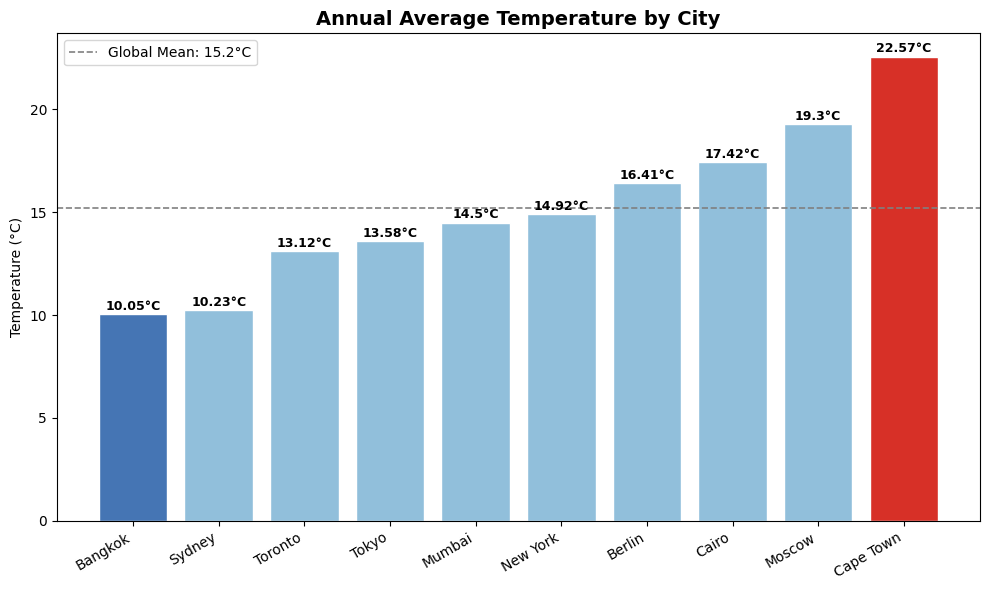

In [5]:
annual_avg = df.mean(axis=1).round(2).sort_values()

colors = ["#d73027" if v == annual_avg.max() else "#4575b4" if v == annual_avg.min() else "#91bfdb" for v in annual_avg]

plt.figure(figsize=(10, 6))
bars = plt.bar(annual_avg.index, annual_avg.values, color=colors, edgecolor="white")

for bar, val in zip(bars, annual_avg.values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.2,
             f"{val}°C", ha="center", fontsize=9, fontweight="bold")

plt.axhline(annual_avg.mean(), color="gray", linestyle="--", linewidth=1.2, label=f"Global Mean: {annual_avg.mean():.1f}°C")
plt.title("Annual Average Temperature by City", fontsize=14, fontweight="bold")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Summary Report

---

### Findings

This analysis used NumPy to generate synthetic monthly temperature data for **10 cities** across **12 months**, with values ranging from -5°C to 35°C.

| Metric | City | Avg Temp |
|---|---|---|
| Hottest | Cape Town | 22.57°C |
| Coldest | Bangkok | 10.05°C |
| Global Mean | — | 15.21°C |

### Observations

- **Cape Town** recorded the highest annual average at 22.57°C, sitting well above the global mean of 15.21°C.
- **Bangkok** recorded the lowest at 10.05°C, despite being a tropical city — a reminder that this is randomly generated data.
- 6 out of 10 cities fell within 2°C of the global mean, indicating a fairly clustered distribution.
- The temperature range (-5°C to 35°C) reflects realistic seasonal variation across different climate zones.

### Tools Used
- **NumPy** — data generation (`np.random.uniform`) and rounding
- **Pandas** — DataFrame creation, `mean(axis=1)`, `idxmax()`, `idxmin()`
- **Matplotlib** — vertical bar chart with conditional coloring and global mean reference line